# 02. EDA

Exploratory analysis on the raw AIS extract from NB01, in two parts.

**Data prep**
- Data quality audit: missing values, duplicates, and aberrant positions. GPS jumps are checked explicitly, some trace back to two vessels broadcasting under the same MMSI, others to isolated point glitches.
- Cleaning: median imputation, interpolation, or drop depending on situation. 
- Resampling to a homogeneous 10-minute time step.
- Track length check, with a minimal eligibility filter to drop vessels too short-lived to be usable.
- Vessel-level train/val/test split. The cleaned dataset is saved before the split.

**Data exploration** (*train set only, to avoid lookahead bias*)
- Visual inspection of vessel trajectories.
- Characterization of trajectory types: stationary, rectilinear, or non-linear, and how that mix shifts as the observation window lengthens.



## Contents

1. Setup & raw data loading
2. Quality check
3. Cleaning
4. Resampling
5. Track length distribution
6. Minimal eligibility filter
7. Train / val / test split
8. Trajectory observation
9. Pipeline note


## AIS fields used here

- **MMSI**: Maritime Mobile Service Identity. Unique vessel identifier in this extract.
- **BaseDateTime**: timestamp of the AIS ping (UTC).
- **LAT** / **LON**: latitude and longitude of the reported position (degrees).
- **SOG**: Speed Over Ground, speed relative to the Earth (knots).
- **COG**: Course Over Ground, direction of movement over the Earth (degrees, 0-359). Distinct from Heading.
- **Heading**: direction the vessel's bow is pointing (degrees). Can differ from COG under drift or current.
- **Status**: navigational status code (e.g. underway, at anchor). Categorical.
- **Length** / **Width** / **Draft**: vessel dimensions (meters).


## 1. Setup & raw data loading


In [1]:
import warnings
from datetime import datetime

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vessel_tracker.config import settings
from vessel_tracker.paths import DATA_RAW
from vessel_tracker.preprocessing import resample_pings, vessel_train_test_split
from vessel_tracker.metrics import haversine_distance

ing = settings.ingestion
bb = ing.bounding_box
coords = f"lon{bb.lon_west:.1f}to{bb.lon_east:.1f}_lat{bb.lat_south:.1f}to{bb.lat_north:.1f}"
start = datetime.strptime(ing.start_date, "%Y-%m-%d").strftime("%Y%m%d")
end = datetime.strptime(ing.end_date, "%Y-%m-%d").strftime("%Y%m%d")
raw_path = DATA_RAW / f"AIS_merged_{coords}_{start}to{end}.parquet"

df_raw = pd.read_parquet(raw_path)
df_raw["BaseDateTime"] = pd.to_datetime(df_raw["BaseDateTime"])
print(f"Raw: {len(df_raw):,} rows, {df_raw['MMSI'].nunique():,} vessels")

Raw: 7,532,915 rows, 2,441 vessels


## 2. Quality check

- We decode encoded missing values: they must be NaN before missingness can be measured. Beyond that, this section only observes: no imputation, no row or vessel drops, no resampling. Cleaning actions are deferred to the next section.


### 2.1 Descriptive statistics


In [2]:
print(f"Unique vessels: {df_raw['MMSI'].nunique():,}")
df_raw.describe()
# Length/Width/Draft = 0 are sentinel-encoded missing values (handled below)

Unique vessels: 2,441


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,Status,Length,Width,Draft
count,7.532915e+06,7532915,7.532915e+06,7.532915e+06,7.532915e+06,7.532915e+06,7.532915e+06,7.520510e+06,7.495378e+06,7.423868e+06,7.521319e+06
mean,4.149121e+08,2024-11-15 17:03:56.703144960,2.788859e+01,-8.844105e+01,5.960109e+00,1.894508e+02,2.072760e+02,9.990495e-01,1.620087e+02,2.737625e+01,7.321785e+00
min,8.000000e+00,2024-11-01 00:00:00,2.250717e+01,-9.503697e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.382930e+08,2024-11-08 13:48:34,2.652947e+01,-9.407607e+01,0.000000e+00,1.016000e+02,9.100000e+01,0.000000e+00,8.800000e+01,1.800000e+01,4.400000e+00
50%,3.676776e+08,2024-11-15 13:53:17,2.877213e+01,-9.019975e+01,3.100000e+00,1.887000e+02,1.800000e+02,0.000000e+00,1.800000e+02,3.000000e+01,7.700000e+00
75%,5.380080e+08,2024-11-22 14:29:54,2.915008e+01,-8.240342e+01,1.180000e+01,2.825000e+02,3.060000e+02,1.000000e+00,2.250000e+02,3.200000e+01,9.700000e+00
max,7.202020e+08,2024-11-30 23:59:59,2.946889e+01,-7.720977e+01,1.023000e+02,3.600000e+02,5.110000e+02,1.500000e+01,5.120000e+02,9.400000e+01,2.550000e+01
std,1.291641e+08,NaN,1.695314e+00,5.699606e+00,6.305038e+00,1.067619e+02,1.424838e+02,2.009188e+00,8.054123e+01,1.172949e+01,3.557651e+00


### 2.2 Duplicates


In [3]:
n_dup = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {n_dup:,}")
# Decision deferred: drop_duplicates() applied in the cleaning section

Exact duplicate rows: 1,394


### 2.3 Missing values


#### 2.3.1 Replace encoded missing values by NaN

Online search shows that missing values in some AIS features are numerically encoded:
- 1022 or more for SOG (appears as 102.2 in the dataset)
- 511 for Heading
- 360 for COG (COG is between 0 and 359)
- 91 for LAT
- 181 for LON
- 0 for Width, Length, Draft


In [4]:
dim_cols = ["Length", "Width", "Draft"]
df_raw[dim_cols] = df_raw[dim_cols].replace(0, np.nan)

df_raw["SOG"] = df_raw["SOG"].where(df_raw["SOG"] < 102.2, np.nan) #where keeps value where condition is True

df_raw["Heading"] = df_raw["Heading"].replace(511, np.nan)
df_raw["COG"] = df_raw["COG"].replace(360, np.nan)
df_raw["LAT"]= df_raw["LAT"].replace(91, np.nan)
df_raw["LON"]= df_raw["LON"].replace(181, np.nan)

#### 2.3.2 Count % of NaN


In [5]:
(df_raw.isna().sum() / len(df_raw) * 100).sort_values(ascending=False)

Heading         9.921923
Draft           4.618518
COG             2.337223
Width           1.831190
Length          0.544995
Status          0.164677
SOG             0.017231
MMSI            0.000000
BaseDateTime    0.000000
LAT             0.000000
LON             0.000000
dtype: float64

#### 2.3.3 Check if NaN are randomly distributed or accumulated in problematic vessels


In [6]:
na_per_vessel = df_raw.groupby("MMSI").agg(lambda x: x.isna().sum())
ping_per_vessel = df_raw.groupby("MMSI").size()
na_pc = na_per_vessel.divide(ping_per_vessel, axis=0) * 100 #percent of nan in a vessel
na_pct_per_vessel = na_pc.loc[na_pc.any(axis=1)] #keep only lines where at least one Na
print(f"Vessels with at least one NaN: {len(na_pct_per_vessel)}")
na_pct_per_vessel.head(10)

Vessels with at least one NaN: 330


,BaseDateTime,LAT,LON,SOG,COG,Heading,Status,Length,Width,Draft
MMSI,,,,,,,,,,
8,0.0,0.0,0.0,0.000000,0.000000,100.000000,100.0,0.0,100.0,0.0
3791472,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,100.0,100.0,100.0
205097000,0.0,0.0,0.0,0.000000,0.088692,0.000000,0.0,0.0,0.0,0.0
209015000,0.0,0.0,0.0,0.016488,0.016488,0.000000,0.0,0.0,0.0,0.0
209729000,0.0,0.0,0.0,0.000000,0.009804,0.009804,0.0,0.0,0.0,0.0
210959000,0.0,0.0,0.0,0.000000,1.343402,3.345333,0.0,0.0,0.0,0.0
212582000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,100.0,0.0
215919000,0.0,0.0,0.0,0.000000,0.029744,0.000000,0.0,0.0,0.0,0.0
219028421,0.0,0.0,0.0,64.591440,64.591440,0.000000,0.0,0.0,0.0,0.0


Missing values for Heading and geometry are concentrated in specific vessels (100% missing).

#### 2.3.4 Missingness of SOG


In [7]:
#analyse gaps in SOG data
sog_temp = df_raw[["MMSI", "BaseDateTime", "SOG"]]
sog_temp = sog_temp.sort_values(by= ["MMSI","BaseDateTime"])
sog_temp = sog_temp.dropna(subset= ["SOG"]) 
#duration of gaps
sog_temp["delta"] = sog_temp.groupby("MMSI")["BaseDateTime"].diff().dt.total_seconds() 
sog_temp["delta"] = sog_temp["delta"] / 60


In [8]:
sog_temp["delta"].describe()

count    7.529176e+06
mean     5.705219e+00
std      1.709615e+02
min      0.000000e+00
25%      1.166667e+00
50%      1.350000e+00
75%      3.000000e+00
max      4.060142e+04
Name: delta, dtype: float64

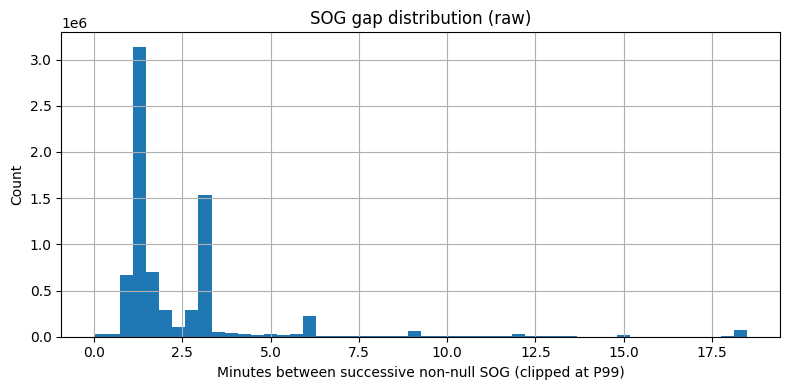

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sog_temp["delta"].clip(upper=sog_temp["delta"].quantile(0.99)).hist(bins=50, ax=ax)
ax.set_xlabel("Minutes between successive non-null SOG (clipped at P99)")
ax.set_ylabel("Count")
ax.set_title("SOG gap distribution (raw)")
plt.tight_layout()
plt.show()


Most SOG gaps are short (99th percentile around 18 min), so we can linearly interpolate them. Gaps longer than 30 minutes are left as NaN.


#### 2.3.5 Missingness of COG


In [10]:
# > 10 means >10% of pings missing COG for that vessel
(na_pct_per_vessel["COG"] > 10).sum()

np.int64(30)

Vessels with a high share of missing COG (30 vessels with more than 10% of pings missing their COG data). COG can be derived from the LAT/LON sequence, so we drop it here and recompute it after resampling if needed during feature engineering.

#### 2.3.6 **Conclusions**

- Missing values are not homogeneously distributed: a few vessels concentrate most of them.
- `Status`: cannot be imputed → **drop the affected rows**.
- `Length` / `Width` / `Draft`: a single global median is imputed as a deliberate fallback. The affected values are concentrated on vessels whose dimensions are fully missing, so a per-vessel median is undefined.
- `SOG`: a continuous, non-random signal → **linear interpolation**, capped at a maximum gap length.
- `COG`: missingness concentrated in specific vessels. COG is recoverable from the LAT/LON sequence, so we **drop the column** rather than lose those vessels, and recompute it during feature engineering if needed.


### 2.4 Pings frequency


In [11]:
df_sorted = df_raw.sort_values(["MMSI", "BaseDateTime"])
delta_min = df_sorted.groupby("MMSI")["BaseDateTime"].diff().dt.total_seconds() / 60
delta_min = delta_min.dropna()

print("Inter-ping interval (minutes), all vessels:")
print(delta_min.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))

median_per_vessel = df_sorted.groupby("MMSI")["BaseDateTime"].apply(
    lambda s: s.diff().dt.total_seconds().median() / 60
)
print(f"\nPer-vessel median interval, mean: {median_per_vessel.mean():.1f} min, "
      f"median: {median_per_vessel.median():.1f} min")


Inter-ping interval (minutes), all vessels:
count    7.530474e+06
mean     5.704235e+00
std      1.709407e+02
min      0.000000e+00
25%      1.166667e+00
50%      1.350000e+00
75%      3.000000e+00
90%      3.350000e+00
99%      1.850000e+01
max      4.060142e+04
Name: BaseDateTime, dtype: float64

Per-vessel median interval, mean: 2.1 min, median: 1.3 min


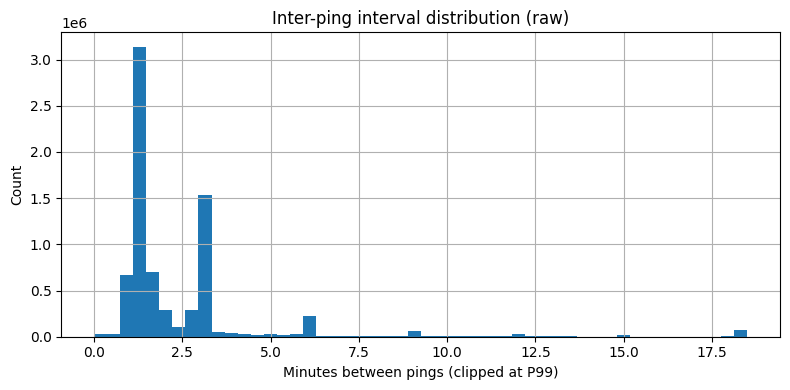

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
delta_min.clip(upper=delta_min.quantile(0.99)).hist(bins=50, ax=ax)
ax.set_xlabel("Minutes between pings (clipped at P99)")
ax.set_ylabel("Count")
ax.set_title("Inter-ping interval distribution (raw)")
plt.tight_layout()
plt.show()

Pings are irregular, which justifies resampling both over time and across vessels.

### 2.5 Check continuity of trajectory
Preliminary tests returned *aberrant speed calculation*, suggesting a risk of "GPS jumps". This must be checked before moving on to cleaning phase. 


In [13]:

trajectory_temp = df_raw[["MMSI", "LAT", "LON", "BaseDateTime"]].copy()
trajectory_temp = trajectory_temp.sort_values(by=["MMSI", "BaseDateTime"]).reset_index(drop=True)

trajectory_temp["interping_duration"] = trajectory_temp.groupby("MMSI")["BaseDateTime"].diff().dt.total_seconds()/3600
lat_prev = trajectory_temp.groupby("MMSI")["LAT"].shift(1)
lon_prev = trajectory_temp.groupby("MMSI")["LON"].shift(1)
trajectory_temp["interping_distance"] = haversine_distance(
    lat_prev, lon_prev,
    trajectory_temp["LAT"], trajectory_temp["LON"],
) / 1.852

trajectory_temp["interping_speed"] = (trajectory_temp["interping_distance"] /trajectory_temp["interping_duration"]).replace(np.inf, np.nan)




In [14]:
trajectory_temp["interping_speed"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.9, 0.95, 0.99, 1.0])

count    7.528961e+06
mean     3.087266e+01
std      2.806940e+03
min      0.000000e+00
1%       0.000000e+00
5%       6.020770e-03
10%      1.620416e-02
25%      5.044244e-02
50%      3.085955e+00
90%      1.402989e+01
95%      1.555256e+01
99%      1.906125e+01
100%     1.304961e+06
max      1.304961e+06
Name: interping_speed, dtype: float64

In [15]:
trajectory_temp["interping_distance"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.9, 0.95, 0.99, 1.0])

count    7.530474e+06
mean     4.368584e-01
std      7.503180e+00
min      0.000000e+00
1%       0.000000e+00
5%       5.241245e-04
10%      7.964686e-04
25%      1.978183e-03
50%      7.104706e-02
90%      3.589914e-01
95%      5.540094e-01
99%      2.302049e+00
100%     8.858455e+02
max      8.858455e+02
Name: interping_distance, dtype: float64

In [16]:
trajectory_temp["interping_duration"].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.9, 0.95, 0.99, 1.0])

count    7.530474e+06
mean     9.507059e-02
std      2.849012e+00
min      0.000000e+00
1%       1.500000e-02
5%       1.750000e-02
10%      1.861111e-02
25%      1.944444e-02
50%      2.250000e-02
90%      5.583333e-02
95%      1.002778e-01
99%      3.083333e-01
100%     6.766903e+02
max      6.766903e+02
Name: interping_duration, dtype: float64

Two anomalies stand out in the distributions above:

- **Extreme inter-ping speeds**: physically impossible values in the tail (up to ~10⁶ kn).
- **Very short inter-ping durations**: sub-minute, sometimes zero. Likely near-duplicate pings (same timestamp, slightly different position) not caught by `drop_duplicates`.

We inspect the worst speed cases below before deciding on a rule.


In [17]:
trajectory_temp.nlargest(5, "interping_speed")

,MMSI,LAT,LON,BaseDateTime,interping_duration,interping_distance,interping_speed
1136158,303294000,29.05250,-78.67906,2024-11-04 18:18:02,0.000278,362.489185,1.304961e+06
1136165,303294000,24.15860,-82.68356,2024-11-04 18:29:22,0.000278,361.189825,1.300283e+06
2362539,356205000,24.96729,-79.49254,2024-11-11 21:47:17,0.000278,291.387657,1.048996e+06
4177459,368295000,28.69937,-80.19095,2024-11-16 00:12:06,0.000278,288.727730,1.039420e+06
4177457,368295000,24.31131,-82.37843,2024-11-16 00:11:00,0.000278,288.716317,1.039379e+06


In [18]:
trajectory_temp[trajectory_temp["MMSI"] == 303294000].sort_values("BaseDateTime").head(50)

,MMSI,LAT,LON,BaseDateTime,interping_duration,interping_distance,interping_speed
1136097,303294000,24.16462,-82.56992,2024-11-04 02:00:01,NaN,NaN,NaN
1136098,303294000,24.16392,-82.57460,2024-11-04 02:01:12,0.019722,0.259790,13.172450
1136099,303294000,24.16323,-82.57923,2024-11-04 02:02:21,0.019167,0.256991,13.408245
1136100,303294000,24.15435,-82.81146,2024-11-04 03:00:12,0.964167,12.733142,13.206371
1136101,303294000,24.15405,-82.81613,2024-11-04 03:01:22,0.019444,0.256473,13.190064
1136102,303294000,24.15370,-82.82140,2024-11-04 03:02:41,0.021944,0.289475,13.191263
1136103,303294000,24.15333,-82.82668,2024-11-04 03:04:01,0.022222,0.290112,13.055023
1136104,303294000,24.15297,-82.83208,2024-11-04 03:05:22,0.022500,0.296623,13.183259
1136105,303294000,24.49806,-81.14872,2024-11-04 12:00:09,8.913056,94.397852,10.590964
1136106,303294000,29.46270,-78.35116,2024-11-04 16:18:14,4.301389,333.513383,77.536208


On this example track, the position alternates between two distant areas:

- **Interpretation**: two vessels broadcasting under the same MMSI. Each sub-track is locally consistent; the absurd speeds appear only at the transitions between them.




Next we count how many tracks contain such jumps:

- **Jump rule**: an inter-ping speed above 50 kn, well above the max speed of a cargo/tanker.

In [19]:
# Share of MMSIs with GPS jumps
trajectory_temp["is_jump"] = trajectory_temp["interping_speed"] > 50
jump_count = trajectory_temp.groupby("MMSI")["is_jump"].sum().sort_values(ascending=False)
jump_count.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5,0.6, 0.7,0.8,0.85, 0.86, 0.9, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0])

count    2441.000000
mean        2.238837
std        14.876703
min         0.000000
1%          0.000000
5%          0.000000
10%         0.000000
25%         0.000000
50%         0.000000
60%         0.000000
70%         0.000000
80%         0.000000
85%         0.000000
86%         1.000000
90%         2.000000
95%         7.000000
96%         9.400000
97%        14.000000
98%        24.200000
99%        54.600000
100%      409.000000
max       409.000000
Name: is_jump, dtype: float64

**Handling Speed anomalies**

Some inter-ping speeds reach ~10⁶ knots (max observed ≈ 1.3×10⁶), physically impossible. Two distinct causes:

- **Shared MMSI**: two real vessels broadcasting under the same ID. Each sub-track is clean; only the transitions between them produce absurd speeds.
- **Isolated GPS glitch**: a single bad ping that immediately returns to the track (sensor glitch).

The jump count per vessel separates the two populations: most vessels have none or a handful (isolated glitches), while a small tail accumulates many (shared identifiers). A single per-vessel threshold won't fit both, so we use a two-pass filter, flagging any inter-ping speed above 50 kn as a jump (well above the ~25 kn ceiling for cargo and tankers):

- **Pass 1: drop the flagged rows.** This removes isolated glitches: if it's just one buggy ping, dropping it will "tape back together" the correct previous and following pings.
- **Pass 2: recompute on the new adjacencies, then drop any vessel that still jumps.** Removing rows creates new neighbours; a vessel that keeps jumping means there is a long-lasting inconsistency, suggested two mixed trajectories, from two vessels broadcasting under same MMSI. These will be dropped. 


Together the two passes remove 626,526 rows and 161 vessels.


## 3. Cleaning

The decisions from the quality audit, applied in order. 

Order: drop duplicates → median-impute ship dimensions → gap-limited SOG interpolation → drop COG → two-pass GPS-jump filter → drop remaining NaNs. Each step reports the running dataset size so the attrition is traceable.


In [20]:


n_rows = len(df_raw)
n_vessels = df_raw["MMSI"].nunique()
print(f"Raw (before cleaning): {n_rows:,} rows, {n_vessels:,} vessels")

# --- Duplicates ---
n_rows_before, n_vessels_before = n_rows, n_vessels
df_clean = df_raw.drop_duplicates()
n_rows, n_vessels = len(df_clean), df_clean["MMSI"].nunique()
print(
    f"After drop_duplicates: {n_rows:,} rows, {n_vessels:,} vessels "
    f"(−{n_rows_before - n_rows:,} rows, −{n_vessels_before - n_vessels} vessels)"
)

# --- Ship dimensions imputation (Length, Width, Draft) ---
dim_cols = ["Length", "Width", "Draft"]
dim_nan_before = df_clean[dim_cols].isna().sum().sum()
df_clean = df_clean.fillna({col: df_clean[col].median() for col in dim_cols})
dim_nan_after = df_clean[dim_cols].isna().sum().sum()
print(f"After dimension imputation: {dim_nan_before:,} NaNs → {dim_nan_after:,} NaNs")
print(f"After dimension imputation: {len(df_clean):,} rows, {df_clean['MMSI'].nunique():,} vessels")

Raw (before cleaning): 7,532,915 rows, 2,441 vessels
After drop_duplicates: 7,531,521 rows, 2,441 vessels (−1,394 rows, −0 vessels)
After dimension imputation: 526,823 NaNs → 0 NaNs
After dimension imputation: 7,531,521 rows, 2,441 vessels


In [21]:

# problems= because pings are irregular, we cannot directly .interpolate(limit= 30)
SOG_MAX_GAP_MIN = 30

def interpolate_sog_gap_limited(df):
    df = df.sort_values("BaseDateTime").copy().reset_index(drop=True)
    is_nan = df["SOG"].isna()

    # keep lines wiehre is_nan is false, convert to NaT the others
    # forward fill the NaT with last know time
    last_known_time = df["BaseDateTime"].where(~is_nan).ffill()  
    next_known_time = df["BaseDateTime"].where(~is_nan).bfill()  # NaN → NaT, then back-fill with next known timestamp
    
    # calculating the difference calcule the gap duration (0 if no gap)
    gap_duration_min = (next_known_time - last_known_time).dt.total_seconds() / 60

    df = df.set_index("BaseDateTime")  # required for method="time"
    
    #interpolate EVERYTHING
    df["SOG"] = df["SOG"].interpolate(method="time", limit_area="inside") 
    df = df.reset_index()

    #set back to NaN the rows that belong to a gap above limit 
    #select if SOG is NA AND gap duration is above threshold
    df.loc[is_nan & (gap_duration_min > SOG_MAX_GAP_MIN), "SOG"] = np.nan
    return df


df_clean = df_clean.sort_values(["MMSI", "BaseDateTime"])
sog_nan_before = df_clean["SOG"].isna().sum()
df_clean = df_clean.groupby("MMSI", group_keys=False).apply(interpolate_sog_gap_limited)
sog_nan_after = df_clean["SOG"].isna().sum()
print(
    f"After SOG imputation (gaps ≤ {SOG_MAX_GAP_MIN} min): "
    f"{sog_nan_before:,} NaNs → {sog_nan_after:,} NaNs"
)
print(
    f"After SOG imputation (gaps ≤ {SOG_MAX_GAP_MIN} min): "
    f"{len(df_clean):,} rows, {df_clean['MMSI'].nunique():,} vessels"
)

After SOG imputation (gaps ≤ 30 min): 1,298 NaNs → 1,040 NaNs
After SOG imputation (gaps ≤ 30 min): 7,531,521 rows, 2,441 vessels


In [22]:
# --- Drop COG: redundant with LAT/LON sequence, missingness concentrated by vessel ---
df_clean = df_clean.drop(columns=["COG"])
print(f"After drop COG: {len(df_clean):,} rows, {df_clean['MMSI'].nunique():,} vessels")

After drop COG: 7,531,521 rows, 2,441 vessels


In [23]:
JUMP_SPEED_MAX_KN = 50

def add_interping_dynamics(df):
    """Per-vessel inter-ping duration (h), distance (NM), speed (kn), jump flag."""
    df = df.sort_values(["MMSI", "BaseDateTime"]).copy()
    df["interping_duration"] = df.groupby("MMSI")["BaseDateTime"].diff().dt.total_seconds() / 3600
    
    # calculate inter-ping distance (NM)
    lat_prev = df.groupby("MMSI")["LAT"].shift(1)
    lon_prev = df.groupby("MMSI")["LON"].shift(1)
    df["interping_distance"] = haversine_distance(
        lat_prev, lon_prev,
        df["LAT"], df["LON"],
    ) / 1.852 
    
    # calculate inter-ping speed (kn)
    df["interping_speed"] = (
        df["interping_distance"] / df["interping_duration"]
    ).replace(np.inf, np.nan)
    
    # flag jumps
    df["is_jump"] = df["interping_speed"] > JUMP_SPEED_MAX_KN
    return df
    

In [24]:
n_rows, n_vessels = len(df_clean), df_clean["MMSI"].nunique()

# Pass 1: flag jumps, drop the rows with jumps (handles isolated GPS spikes)
flagged = add_interping_dynamics(df_clean)
df_clean = flagged[~flagged["is_jump"]] #keep only rows with is_jump is False

# Pass 2: re-flag; drop any vessel that still jumps
flagged = add_interping_dynamics(df_clean)
vessels_with_residual_jump = flagged.loc[flagged["is_jump"], "MMSI"].unique()
df_clean = flagged[~flagged["MMSI"].isin(vessels_with_residual_jump)]

# drop temp columns
df_clean = df_clean.drop(
    columns=["interping_duration", "interping_distance", "interping_speed", "is_jump"]
)

n_rows_after, n_vessels_after = len(df_clean), df_clean["MMSI"].nunique()
print(
    f"After GPS jump filter: {n_rows_after:,} rows, {n_vessels_after:,} vessels "
    f"(−{n_rows - n_rows_after:,} rows, −{n_vessels - n_vessels_after} vessels)"
)


After GPS jump filter: 6,904,995 rows, 2,280 vessels (−626,526 rows, −161 vessels)


In [25]:

# --- Drop rows with remaining NaNs ---
n_rows_before = len(df_clean)
n_vessels_before = df_clean["MMSI"].nunique()
df_clean = df_clean.dropna()
n_rows, n_vessels = len(df_clean), df_clean["MMSI"].nunique()
print(
    f"After dropna: {n_rows:,} rows, {n_vessels:,} vessels "
    f"(−{n_rows_before - n_rows:,} rows, −{n_vessels_before - n_vessels} vessels)"
)

After dropna: 6,167,266 rows, 2,200 vessels (−737,729 rows, −80 vessels)


In [26]:
df_clean.describe()

,BaseDateTime,MMSI,LAT,LON,SOG,Heading,Status,Length,Width,Draft
count,6167266,6.167266e+06,6.167266e+06,6.167266e+06,6.167266e+06,6.167266e+06,6.167266e+06,6.167266e+06,6.167266e+06,6.167266e+06
mean,2024-11-15 16:51:46.802130432,4.188301e+08,2.792694e+01,-8.872825e+01,6.107379e+00,1.745611e+02,9.244498e-01,1.730697e+02,2.895001e+01,7.939247e+00
min,2024-11-01 00:00:00,3.791472e+06,2.250729e+01,-9.503697e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,3.000000e+00,1.000000e-01
25%,2024-11-08 14:59:55.249999872,3.380020e+08,2.676994e+01,-9.438118e+01,0.000000e+00,8.700000e+01,0.000000e+00,1.000000e+02,2.000000e+01,5.700000e+00
50%,2024-11-15 14:18:42.500000,3.680420e+08,2.875259e+01,-9.020248e+01,4.300000e+00,1.610000e+02,0.000000e+00,1.830000e+02,3.000000e+01,8.000000e+00
75%,2024-11-22 10:56:35.750000128,5.380092e+08,2.914571e+01,-8.251895e+01,1.190000e+01,2.690000e+02,1.000000e+00,2.280000e+02,3.200000e+01,9.800000e+00
max,2024-11-30 23:59:59,6.770623e+08,2.946889e+01,-7.720977e+01,6.060000e+01,3.590000e+02,1.500000e+01,5.120000e+02,9.400000e+01,2.550000e+01
std,NaN,1.333515e+08,1.658283e+00,5.677634e+00,6.172124e+00,1.063698e+02,1.794721e+00,7.539444e+01,1.087782e+01,3.072681e+00


## 4. Resampling

**10-minute bins** : a trade-off between temporal granularity and sequence length for the learned models. Stored in `configs/default.yaml` → `resample_interval_min`.

Each bin takes the value of its last ping. Empty bins are filled by column type: linear interpolation for continuous fields (position, speed, dimensions, with a constant-velocity assumption for position), forward-fill for Heading (circular: linear interpolation would cause problems at the 0/360 wrap) and Status (categorical: status is just numerically encoded , a mean does not make sense here). 


In [27]:
df_resampled = resample_pings(df_clean)  # default = settings.resample_interval_min
print(
    f"After resample ({settings.resample_interval_min} min): "
    f"{len(df_resampled):,} rows, {df_resampled['MMSI'].nunique():,} vessels"
)

After resample (10 min): 3,661,138 rows, 2,200 vessels


In [28]:
df_resampled.describe()

,MMSI,BaseDateTime,LAT,LON,SOG,Heading,Status,Length,Width,Draft
count,3.661138e+06,3661138,3.661138e+06,3.661138e+06,3.661138e+06,3.661138e+06,3.661138e+06,3.661138e+06,3.661138e+06,3.661138e+06
mean,4.241739e+08,2024-11-16 04:12:25.334320384,2.758687e+01,-8.903245e+01,8.232528e+00,1.990252e+02,8.028072e-01,1.787024e+02,2.964180e+01,8.284065e+00
min,3.791472e+06,2024-11-01 00:00:00,2.250737e+01,-9.503695e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,3.000000e+00,1.000000e-01
25%,3.110009e+08,2024-11-09 18:50:00,2.607915e+01,-9.409013e+01,3.000000e-01,1.100000e+02,0.000000e+00,1.390000e+02,2.200000e+01,6.600000e+00
50%,3.683245e+08,2024-11-16 07:40:00,2.844264e+01,-9.019754e+01,1.080275e+01,2.000000e+02,0.000000e+00,1.830000e+02,3.200000e+01,8.284042e+00
75%,5.380103e+08,2024-11-22 15:00:00,2.930808e+01,-8.566464e+01,1.262562e+01,2.970000e+02,0.000000e+00,2.270000e+02,3.200000e+01,1.010000e+01
max,6.770623e+08,2024-11-30 23:50:00,2.946889e+01,-7.720977e+01,3.450000e+01,3.590000e+02,1.500000e+01,5.120000e+02,9.400000e+01,2.550000e+01
std,1.397483e+08,NaN,1.982531e+00,5.392381e+00,5.930910e+00,1.073769e+02,1.832825e+00,6.822471e+01,1.021836e+01,2.914369e+00


## 5. Track length distribution



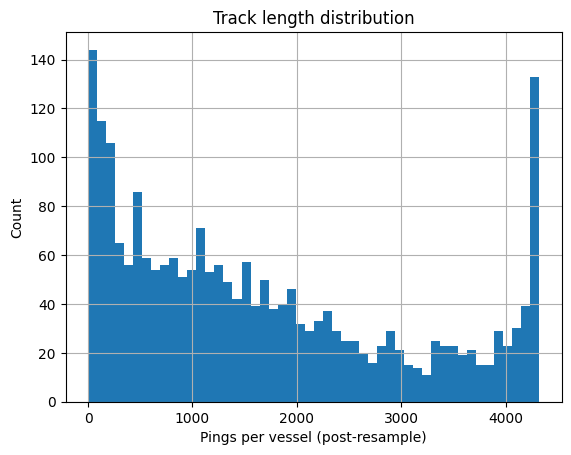

In [29]:
track_len = df_resampled.groupby("MMSI").size()
track_len.hist(bins=50)
plt.xlabel("Pings per vessel (post-resample)")
plt.ylabel("Count")
plt.title("Track length distribution")
plt.show()

The distribution is bimodal: a peak at short tracks and a peak at long tracks.

- **Short tracks**: likely vessels that enter and leave the bounding box almost immediately → candidates for filtering.
- **Long tracks**: likely mostly-static vessels that persist over the whole window.


## 6. Minimal eligibility filter

We don't yet know the final prediction horizon, but vessels that stay in the Gulf only briefly won't provide enough pings to be usable.

We assume the shortest window we'll use is 2 h (a 1 h horizon plus 1 h of lookback), and keep only vessels with at least that many steps.


In [30]:
# Exploratory window_h grid 
time_windows_h = [1, 2, 3, 4, 5, 6, 8, 10, 12, 18, 24, 30, 36, 42, 48] #time window duration to explore and characterize the vessel trajectory
RESAMPLE_MIN = settings.resample_interval_min

In [31]:
# Floor: minimal track length to be usable downstream. The final lookback/horizon
# at least 2h of track at the current resample interval.
min_steps = int(2 * 60 / RESAMPLE_MIN)
print(f"Minimal filter: {min_steps} steps (≥ 2h @ {RESAMPLE_MIN} min)")

track_len = df_resampled.groupby("MMSI").size()
eligible_mmsi = track_len[track_len >= min_steps].index
n_excluded = df_resampled["MMSI"].nunique() - len(eligible_mmsi)

print(
    f"Vessels kept: {len(eligible_mmsi)} / {len(track_len)} "
    f"(excluded: {n_excluded})"
)

df_resampled = df_resampled[df_resampled["MMSI"].isin(eligible_mmsi)].copy()
print(f"After minimal filter: {len(df_resampled):,} rows, {df_resampled['MMSI'].nunique():,} vessels")

Minimal filter: 12 steps (≥ 2h @ 10 min)
Vessels kept: 2173 / 2200 (excluded: 27)
After minimal filter: 3,661,057 rows, 2,173 vessels


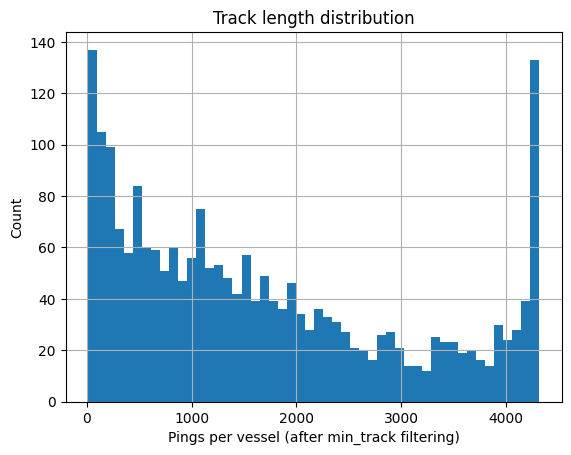

In [32]:
track_len = df_resampled.groupby("MMSI").size()
track_len.hist(bins=50)
plt.xlabel("Pings per vessel (after min_track filtering)")
plt.ylabel("Count")
plt.title("Track length distribution")
plt.show()

The filter removes only 27 of 2,200 vessels, so the distribution is essentially unchanged. A stronger filter may be applied later, once the horizon is fixed.

In [33]:
# --- Save cleaned + resampled dataset ---

from vessel_tracker.paths import DATA_PROCESSED

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
processed_path = DATA_PROCESSED / f"AIS_clean_resampled_{settings.resample_interval_min}min.parquet"
df_resampled.to_parquet(processed_path, index=False)
print(f"Saved: {processed_path} ({len(df_resampled):,} rows, {df_resampled['MMSI'].nunique():,} vessels)")


Saved: /Users/pablorougerie/code/Projets/shanty_project/data/processed/AIS_clean_resampled_10min.parquet (3,661,057 rows, 2,173 vessels)


## 7. Train / val / test split

Ratios from `settings.split_ratios` (70/15/15). No MMSI is shared across sets.


In [34]:
# function operates a MMSI-grouped train/val/test split, with no overlap verification
df_train, df_val, df_test, *_ = vessel_train_test_split(
    df_resampled,
    test_size=settings.split_ratios.test,
    val_size=settings.split_ratios.val,
    random_state=settings.random_seed,
)
for name, part in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"{name}: {len(part):,} rows, {part['MMSI'].nunique():,} vessels")

train: 2,570,295 rows, 1,521 vessels
val: 548,825 rows, 326 vessels
test: 541,937 rows, 326 vessels


## 8. Trajectory observation
Analyze on `df_train` only to avoid leaking knowledge from eval or test sets. 


In [35]:
from vessel_tracker.features import path_length_km, straightness_index

RESAMPLE_MIN = settings.resample_interval_min


### 8.1 Visual observation of tracks


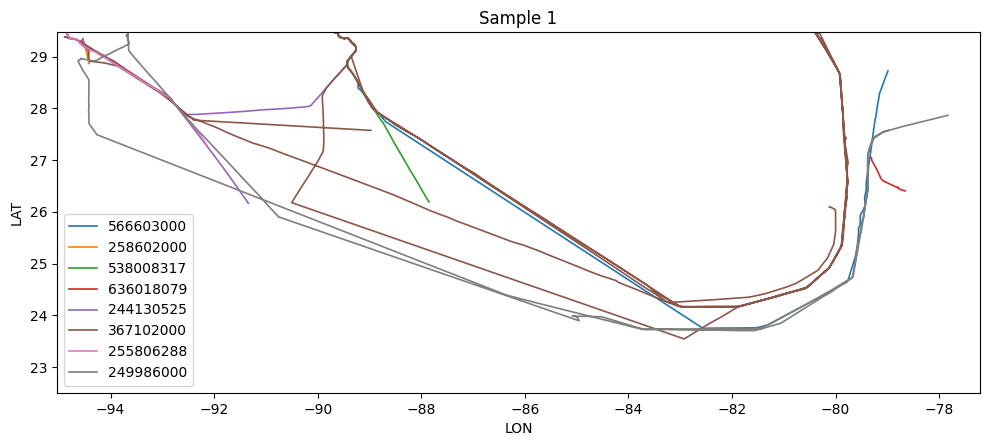

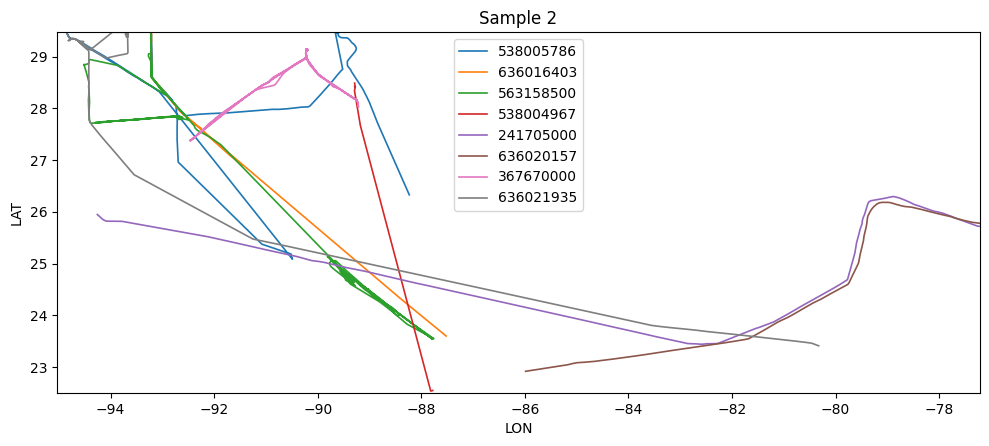

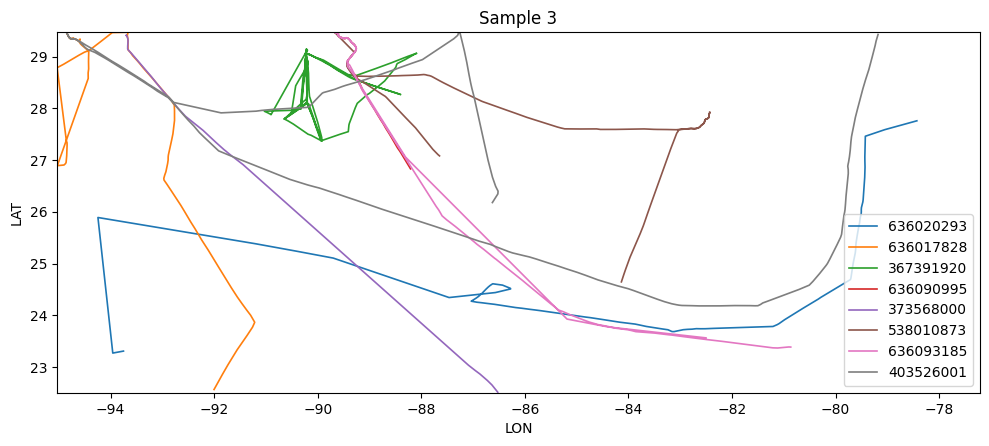

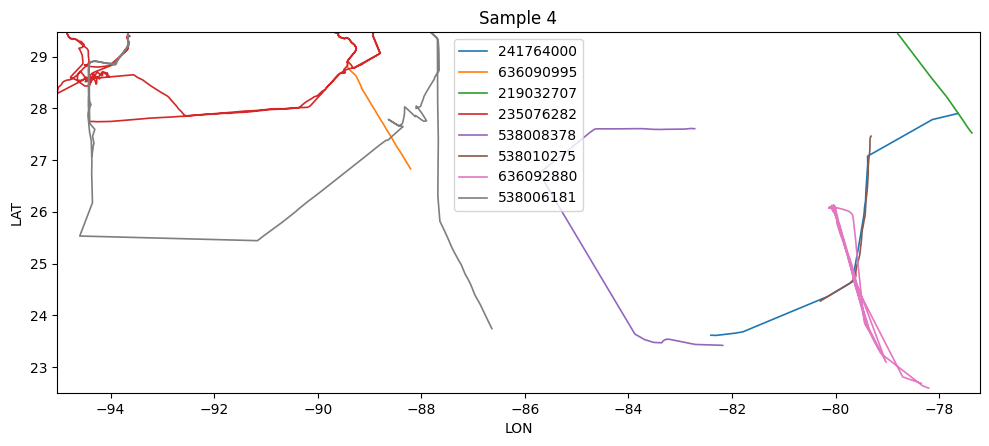

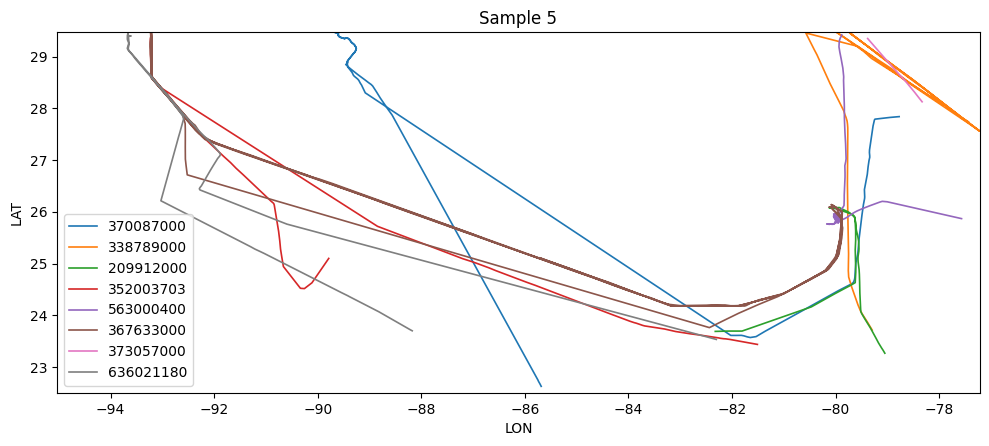

In [36]:
mmsi_all = df_train["MMSI"].unique()
rng = np.random.default_rng(settings.random_seed)
colors = plt.cm.tab10.colors
lon_lim = df_train["LON"].min(), df_train["LON"].max()
lat_lim = df_train["LAT"].min(), df_train["LAT"].max()

for i in range(5):
    sample = rng.choice(mmsi_all, size=8, replace=False)
    fig, ax = plt.subplots(figsize=(10, 8))
    for color, mmsi in zip(colors, sample):
        v = df_train[df_train["MMSI"] == mmsi].sort_values("BaseDateTime")
        ax.plot(v["LON"], v["LAT"], color=color, linewidth=1.2, label=str(mmsi))
    ax.set_xlim(lon_lim)
    ax.set_ylim(lat_lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("LON")
    ax.set_ylabel("LAT")
    ax.legend()
    ax.set_title(f"Sample {i + 1}")
    plt.tight_layout()
    plt.show()

Visual inspection of the trajectories surfaces a few recurring patterns:

- **Straight segments**: transit at near-constant course.
- **Curved segments**: from smooth turns to more erratic maneuvering.
- **Near-stationary vessels**: anchored or drifting, little net displacement.

Critically, a single vessel moves through several of these regimes over its track: a tanker may transit straight, maneuver, then sit at anchor.

Two consequences follow:

**1. Position predictability is regime-dependent.** A straight, constant-speed segment is near-trivial to extrapolate; an anchored or maneuvering segment is not. A sudden change of regime is also hard (straight and then sudden turn). Within a single track, predictability varies with the regime of the current segment and the number of regime changes.

**2. The horizon controls the regime mix inside a window, not a model per regime.** A longer horizon spans a longer window, which is more likely to contain a regime change (a turn, a stop, a departure). The trajectory then becomes composite and departs from a straight line. The higher probability of having a composite trajectory makes longer horizons progressively harder. 

Working hypothesis: at short horizons the window stays mostly single-regime and near-linear, so a physics baseline should work. As the horizon lengthens, composite trajectories accumulate, and predicting them may require models more expressive than simple geometric extrapolation. Which kind of model, and how much it helps at each horizon, is tested in the following notebooks.


### 8.2 Vessel stationarity and straightness

- **effective speed**: actual distance of the vessel's track divided by time 
- **straightness**: ratio between straight path and actual path (1 = perfectly rectilinear)


In [37]:
vessel_speed_by_mmsi = {}
straightness_by_mmsi = {}
#calculate effective speed and straighness by vessel
for mmsi, grp in df_train.groupby("MMSI"):
    grp = grp.sort_values("BaseDateTime")
    duration_h = (
        grp["BaseDateTime"].iloc[-1] - grp["BaseDateTime"].iloc[0]
    ).total_seconds() / 3600
    path_km = path_length_km(grp["LAT"].to_numpy(), grp["LON"].to_numpy()) #length of actual path
    vessel_speed_by_mmsi[mmsi] = (path_km / 1.852) / duration_h #speed in KN
    
    straightness = straightness_index(grp["LAT"].to_numpy(), grp["LON"].to_numpy())
    straightness_by_mmsi[mmsi] = straightness

vessel_speed_by_mmsi = pd.Series(vessel_speed_by_mmsi, name="effective_speed_knots")
straightness_by_mmsi = pd.Series(straightness_by_mmsi, name="trajectory_straighness")


#### 8.2.1 Speed


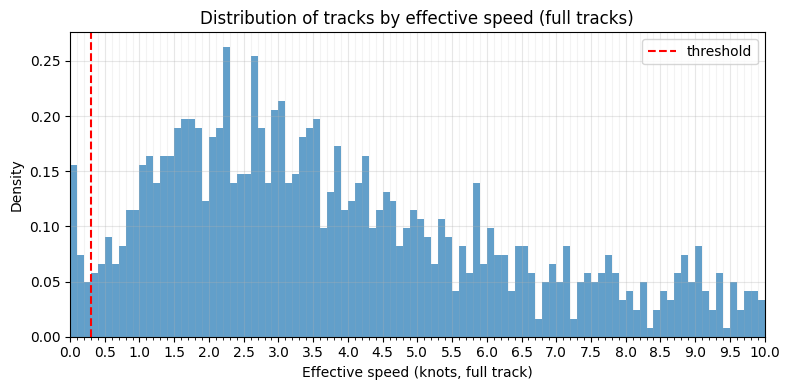

Share of vessels below threshold: 2.2%
number of stationary vessels: 34


In [38]:
stationary_speed_threshold = 0.3  # adjusted empirically
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(vessel_speed_by_mmsi, bins=100, density=True, alpha=0.7, range=(0, 10))
ax.axvline(stationary_speed_threshold, color="red", linestyle="--", label="threshold")
ax.set_xlim(0, 10)
ax.set_xticks(np.arange(0, 10.1, 0.5))
ax.set_xticks(np.arange(0, 10.1, 0.1), minor=True)
ax.set_xlabel("Effective speed (knots, full track)")
ax.set_ylabel("Density")
ax.set_title("Distribution of tracks by effective speed (full tracks)")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.15)
ax.legend()
fig.tight_layout()
plt.show()
print(f"Share of vessels below threshold: {(vessel_speed_by_mmsi < stationary_speed_threshold).mean():.1%}")
print(f"number of stationary vessels: {(vessel_speed_by_mmsi < stationary_speed_threshold).sum()}")

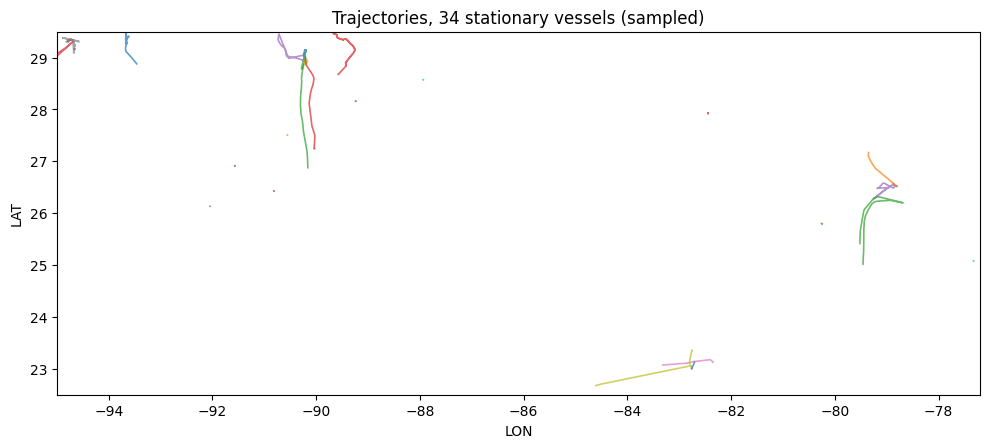

In [39]:
n = 40  # number of stationary vessels to plot

stationary_mmsi = vessel_speed_by_mmsi[
    vessel_speed_by_mmsi < stationary_speed_threshold
].index

rng = np.random.default_rng(settings.random_seed)
sample_stationary = rng.choice(
    stationary_mmsi.to_numpy(),
    size=min(n, len(stationary_mmsi)),
    replace=False,
)

bb = settings.ingestion.bounding_box
fig, ax = plt.subplots(figsize=(10, 8))
for mmsi in sample_stationary:
    v = df_train[df_train["MMSI"] == mmsi].sort_values("BaseDateTime")
    ax.plot(v["LON"], v["LAT"], linewidth=1.2, alpha=0.7)
ax.set_xlim(bb.lon_west, bb.lon_east)
ax.set_ylim(bb.lat_south, bb.lat_north)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("LON")
ax.set_ylabel("LAT")
ax.set_title(f"Trajectories, {len(sample_stationary)} stationary vessels (sampled)")
plt.tight_layout()
plt.show()


A 0.3 knots cutoff, determine from the histogram distribution accurately isolate the non moving or almost not-moving vessels


#### 8.2.2 Straightness


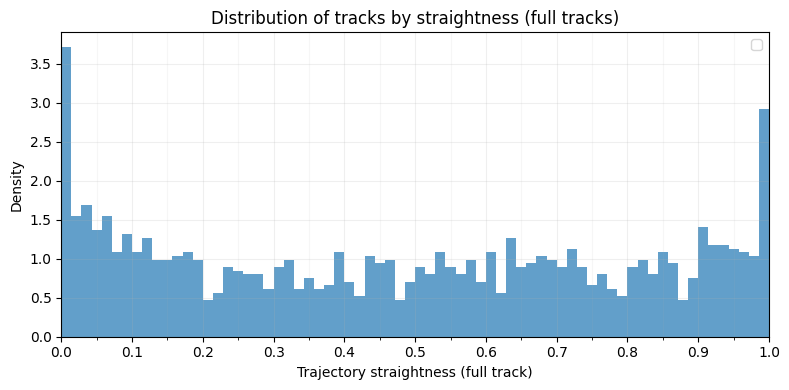

In [40]:
# keep mmsi that are moving
straightness = straightness_by_mmsi.loc[
    vessel_speed_by_mmsi >= stationary_speed_threshold
].dropna()



fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(
    straightness,
    bins=70,
    range=(0, 1),
    density=True,
    alpha=0.7,
)

ax.set_xlim(0, 1)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.set_xticks(np.arange(0, 1.01, 0.05), minor=True)
ax.set_xlabel("Trajectory straightness (full track)")
ax.set_ylabel("Density")
ax.set_title("Distribution of tracks by straightness (full tracks)")
ax.grid(True, which="major", alpha=0.2)
ax.grid(True, which="minor", alpha=0.1)
ax.legend()
fig.tight_layout()
plt.show()



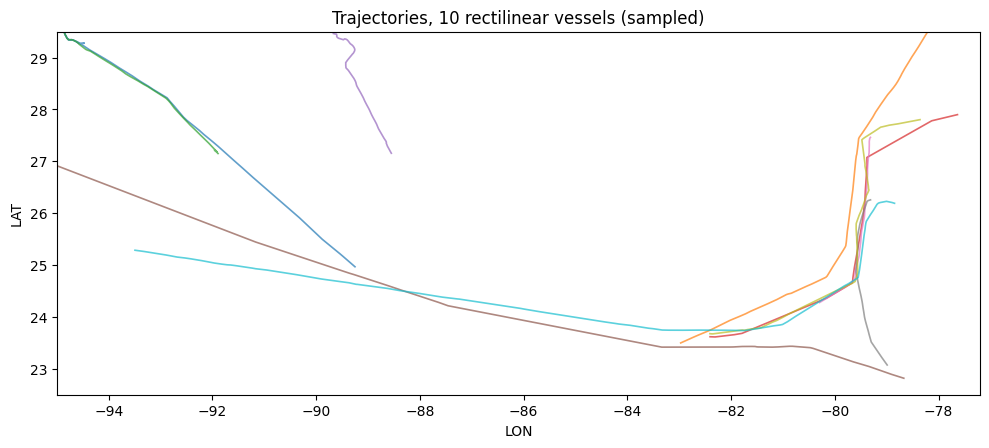

In [41]:
n = 10  # number of rectilinear vessels to plot

#showing high straightness tracks
rectilinear_mmsi = straightness[
    straightness >= 0.8
].index

rng = np.random.default_rng(settings.random_seed)
sample_rectilinear = rng.choice(
    rectilinear_mmsi.to_numpy(),
    size=min(n, len(rectilinear_mmsi)),
    replace=False,
)

bb = settings.ingestion.bounding_box
fig, ax = plt.subplots(figsize=(10, 8))
for mmsi in sample_rectilinear:
    v = df_train[df_train["MMSI"] == mmsi].sort_values("BaseDateTime")
    ax.plot(v["LON"], v["LAT"], linewidth=1.2, alpha=0.7)
ax.set_xlim(bb.lon_west, bb.lon_east)
ax.set_ylim(bb.lat_south, bb.lat_north)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("LON")
ax.set_ylabel("LAT")
ax.set_title(f"Trajectories, {len(sample_rectilinear)} rectilinear vessels (sampled)")
plt.tight_layout()
plt.show()


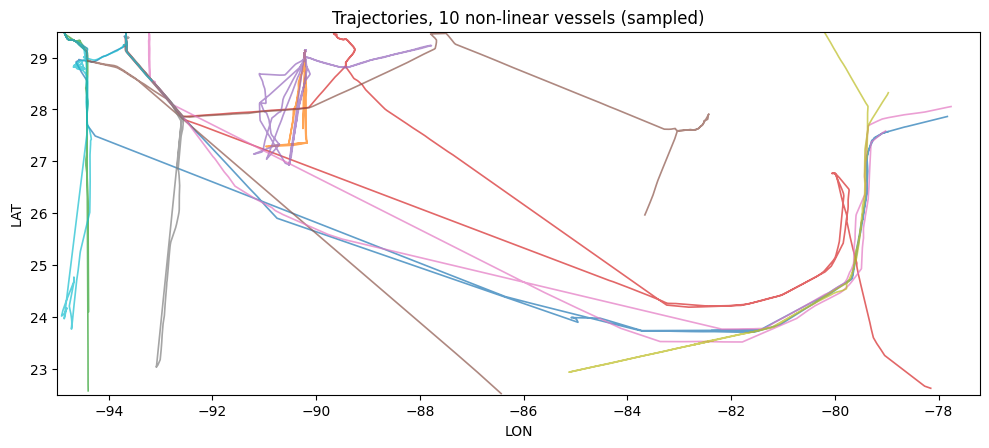

In [42]:
n = 10  # number of non-linear vessels to plot

nonlinear_mmsi = straightness[
    straightness <= 0.2
].index

rng = np.random.default_rng(settings.random_seed)
sample_nonlinear = rng.choice(
    nonlinear_mmsi.to_numpy(),
    size=min(n, len(nonlinear_mmsi)),
    replace=False,
)

bb = settings.ingestion.bounding_box
fig, ax = plt.subplots(figsize=(10, 8))
for mmsi in sample_nonlinear:
    v = df_train[df_train["MMSI"] == mmsi].sort_values("BaseDateTime")
    ax.plot(v["LON"], v["LAT"], linewidth=1.2, alpha=0.7)
ax.set_xlim(bb.lon_west, bb.lon_east)
ax.set_ylim(bb.lat_south, bb.lat_north)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("LON")
ax.set_ylabel("LAT")
ax.set_title(f"Trajectories, {len(sample_nonlinear)} non-linear vessels (sampled)")
plt.tight_layout()
plt.show()


### 8.3 Distribution of effective speed and straightness by time windows

Effective speed and straightness on full track gives an idea of the diversity of tracks and the relevant metrics, but what matters for prediction is the track by time window. 

The assumption is that increasing the time window (like what happens when trying to forecast farther into the future) increase the number of composite, nonlinear trajectories (vessels stopping, maneuvering, changing speed etc), and make it more challenging for simple models. 

We expect a decrease in straightness as time window increases.


#### 8.3.1 Straightness by time window


In [43]:
# Exploratory window grid (hours), same as section 6
time_windows_h = [1, 2, 3, 4, 5, 6, 8, 10, 12, 18, 24, 30, 36, 42, 48]
RESAMPLE_MIN = settings.resample_interval_min

straightness_by_window_h = {}
speed_by_window_h = {}
stationary_count_by_window_h = {}

# iterate through time widon durations
for window_h in time_windows_h:
    print(f"{window_h}h time window...")
    window_h_steps = int(window_h * 60 / RESAMPLE_MIN)  # steps in one window of duration window_h
    min_track_steps = window_h_steps  # need at least one full window to characterize
    straightness_values = []
    speed_values = []
    n_windows = 0                   # total number of windows for each window_h
    n_stationary = 0                # total number of windows ruled as stationary per window_h 
    for _, grp in df_train.groupby("MMSI"):
        grp = grp.sort_values("BaseDateTime")
        if len(grp) < min_track_steps:
            continue #skip track if not enough steps 
        lat = grp["LAT"].to_numpy()
        lon = grp["LON"].to_numpy()
        all_window_starts = range(0, len(grp) - window_h_steps + 1, window_h_steps) #all starts of windows of length window_h 
        
        
        for start_idx in all_window_starts:
            n_windows += 1 
            lat_window = lat[start_idx : start_idx + window_h_steps]
            lon_window = lon[start_idx : start_idx + window_h_steps]
            path_km = path_length_km(lat_window, lon_window) #get the cumulative ditance of the track
            speed_kn = (path_km / 1.852) / window_h
            speed_values.append(speed_kn)

            if speed_kn < stationary_speed_threshold:
                n_stationary += 1
                continue
            straightness_values.append(straightness_index(lat_window, lon_window))
    straightness_by_window_h[window_h] = np.array(straightness_values) #straightness for all tracks of a given time window
    speed_by_window_h[window_h] = np.array(speed_values)
    stationary_count_by_window_h[window_h] = n_stationary



1h time window...
2h time window...
3h time window...
4h time window...
5h time window...
6h time window...
8h time window...
10h time window...
12h time window...
18h time window...
24h time window...
30h time window...
36h time window...
42h time window...
48h time window...


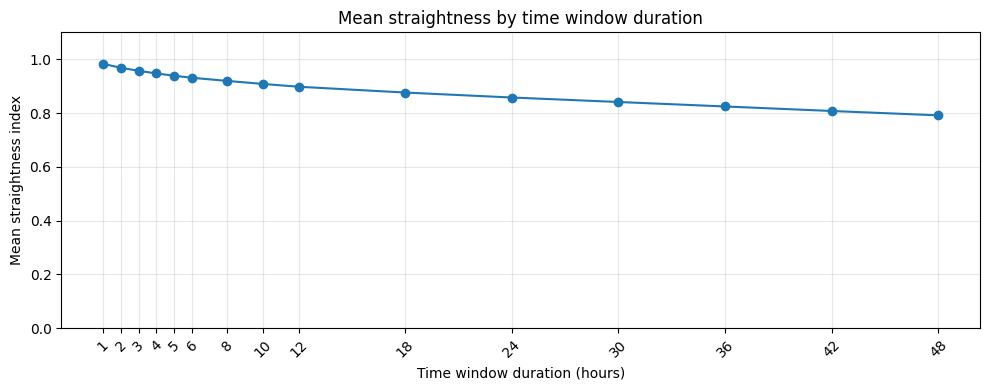

In [44]:
# mean straightness by time window (non-stationary tracks only, see computation loop)
mean_straightness = np.array([straightness_by_window_h[w].mean() for w in time_windows_h])

y_max = 1.1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_windows_h, mean_straightness, marker="o")
ax.set_xticks(time_windows_h)
ax.tick_params(axis="x", rotation=45)
ax.set_xlabel("Time window duration (hours)")
ax.set_ylabel("Mean straightness index")
ax.set_title("Mean straightness by time window duration")
ax.set_ylim(0, y_max)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


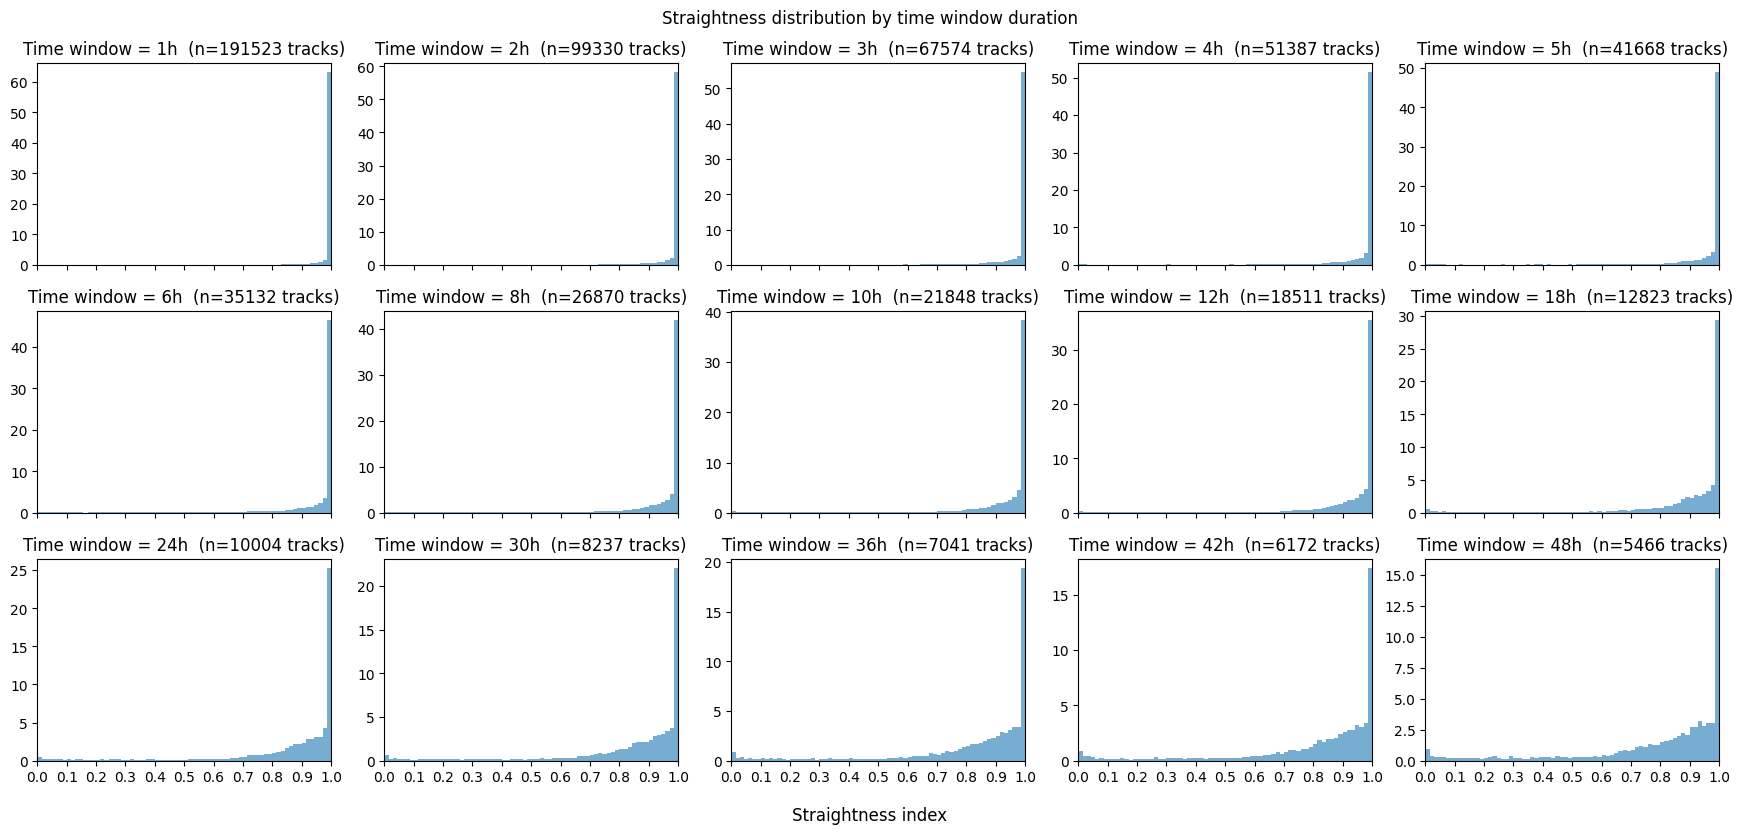

In [45]:

# straightness histogram distribution by time window duration
ncols = 5
nrows = int(np.ceil(len(time_windows_h) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows), sharex=True)
axes = axes.ravel()

for ax, window_h in zip(axes, time_windows_h):
    data = straightness_by_window_h[window_h]
    ax.hist(data, bins=70, range=(0, 1), density=True, alpha=0.6)
    ax.set_title(f"Time window = {window_h}h  (n={len(data)} tracks)")
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.01, 0.1))

for ax in axes[len(time_windows_h):]:
    ax.axis("off")

fig.supxlabel("Straightness index")
fig.suptitle("Straightness distribution by time window duration")
plt.tight_layout()
plt.show()




Straightness indeed decreases over time but remains generally over 0.8 so vessels in high sea overall follow directional trajectories (as expected) suggested that simple position extrapolation or linear model may provide a decent prediction for most tracks. 


#### 8.3.2 Effective speed by time window


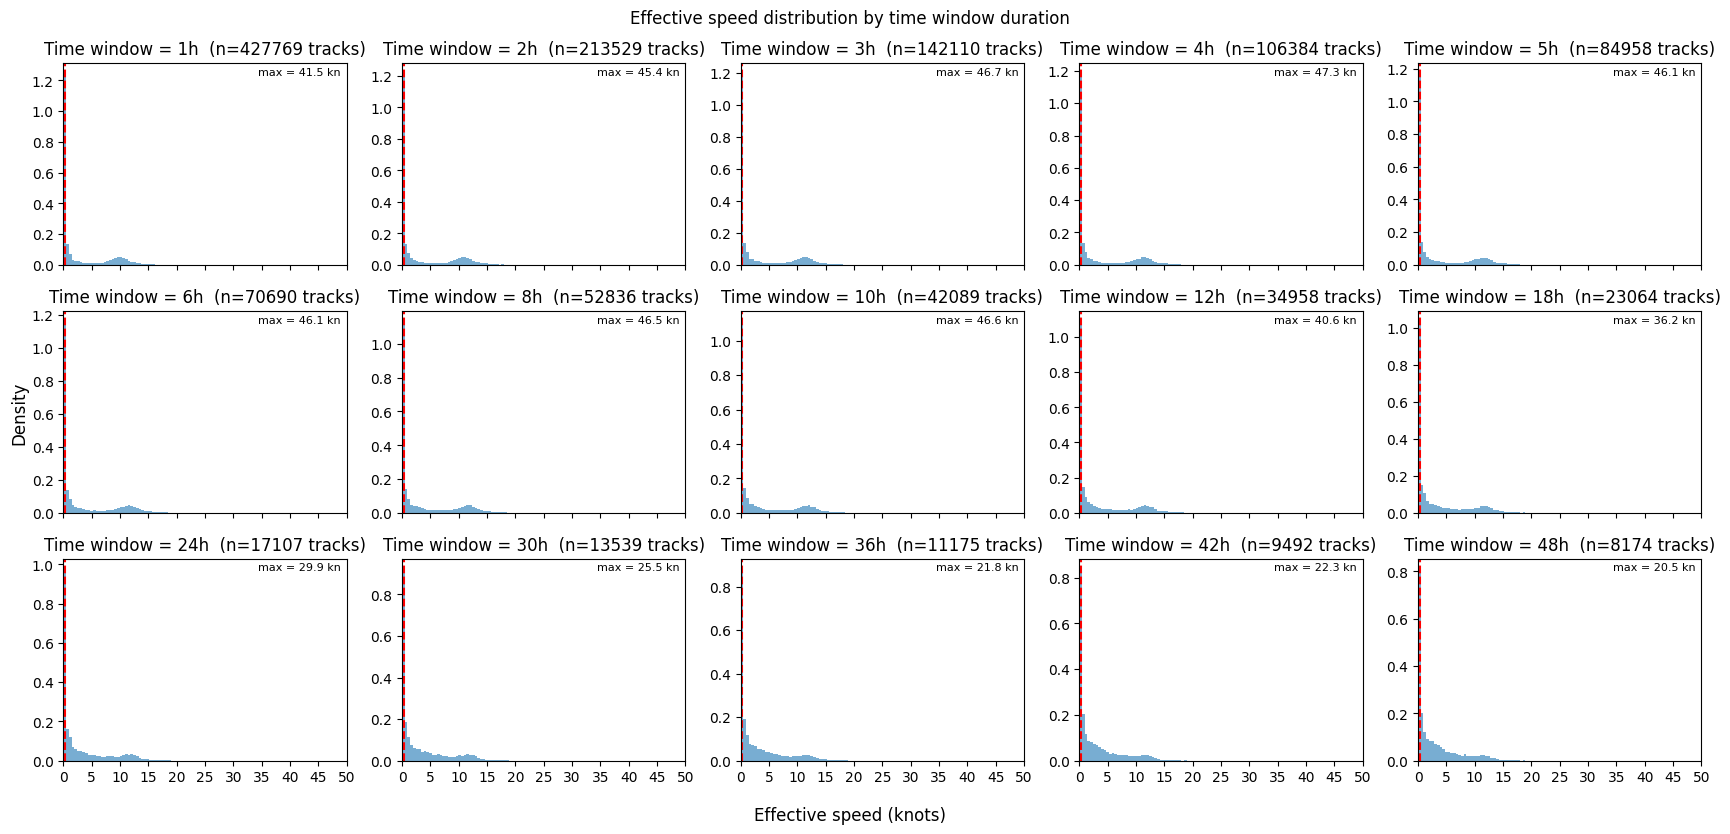

In [46]:
# effective speed distribution histogram by time window
ncols = 5
nrows = int(np.ceil(len(time_windows_h) / ncols))

all_speeds = np.concatenate([speed_by_window_h[window_h] for window_h in time_windows_h if len(speed_by_window_h[window_h])])
speed_xmax = all_speeds.max()
speed_ticks = np.arange(0, int(np.ceil(speed_xmax / 5)) * 5 + 0.01, 5)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows), sharex=True)
axes = axes.ravel()

for ax, window_h in zip(axes, time_windows_h):
    data = speed_by_window_h[window_h]
    ax.hist(data, bins=100, range=(0, speed_xmax), density=True, alpha=0.6)
    ax.axvline(stationary_speed_threshold, color="red", linestyle="--")
    ax.set_title(f"Time window = {window_h}h  (n={len(data)} tracks)")
    ax.set_xlim(0, speed_xmax)
    ax.set_xticks(speed_ticks)
    ax.text(
        0.98, 0.98, f"max = {data.max():.1f} kn",
        transform=ax.transAxes, ha="right", va="top", fontsize=8,
    )

for ax in axes[len(time_windows_h):]:
    ax.axis("off")

fig.supxlabel("Effective speed (knots)")
fig.supylabel("Density")
fig.suptitle("Effective speed distribution by time window duration")
plt.tight_layout()
plt.show()

At short windows, the distribution is roughly bimodal: a peak near 0 kn (near-stationary) and a secondary mass around transit speeds (~10-15 kn).

As the window lengthens, that second mode flattens and extreme speeds become rarer. This is compatible with longer windows averaging mixed regimes (transit, maneuver, stop), though other factors can contribute (fewer long windows, different vessel mix). The plot alone does not prove composition; it only shows that the short-window bimodality weakens at longer horizons.


## 9. Conclusion

- **Cleaning attrition:** **7.53M → 6.17M** rows, **2,441 → 2,200** vessels (dedup, dimension median-impute, gap-limited SOG interpolation, COG drop, two-pass GPS-jump filter, dropna).
- **After 10-min resample and the 2h minimal filter:** **3,661,057** rows / **2,173** vessels, saved before a vessel-level 70/15/15 split (train **1,521** / val **326** / test **326**, no shared MMSI).
- **EDA (train only):** three regimes (stationary, rectilinear, non-linear); straightness mostly **> 0.8**, decreasing slightly as the window lengthens; difficulty is regime-dependent, and a longer horizon raises the share of composite tracks.
- **Next:** deterministic baselines and lookback selection (NB03).
